##INCLUDES

In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from google.colab import drive

##RECUPERATION DU DATASET

In [3]:
drive.mount('/content/drive')
chemin_zip = "/content/drive/MyDrive/projet_AlexNet/dl4cv-coin-classification.zip"
dossier_extraction = "/content/dataset_pieces/"
if not os.path.exists(dossier_extraction):
    with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
        zip_ref.extractall(dossier_extraction)
    print("Extraction terminée !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##PRE-TRAITEMENT DU DATASET

In [29]:
class CoinDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        raw_df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        valid_extensions = ('.png', '.jpg', '.jpeg', '.webp', '.PNG', '.JPG', '.JPEG', '.WEBP')

        files = [f for f in os.listdir(img_dir) if f.lower().endswith(valid_extensions)]
        self.id_to_filename = {f.split('.')[0]: f for f in files}

        self.df = raw_df[raw_df.iloc[:, 0].astype(str).isin(self.id_to_filename.keys())].reset_index(drop=True)

        self.encoder = LabelEncoder()
        self.labels = self.encoder.fit_transform(self.df.iloc[:, 1])

        print(f"✅ Dataset prêt : {len(self.df)} images valides.")
        print(f"❌ {len(raw_df) - len(self.df)} fichiers invalides ignorés.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = str(self.df.iloc[idx, 0])
        filename = self.id_to_filename[img_id]
        img_path = os.path.join(self.img_dir, filename)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

data_transforms = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = CoinDataset("/content/dataset_pieces/kaggle/train.csv",
                           "/content/dataset_pieces/kaggle/train/",
                           transform=data_transforms)

train_set, val_set = random_split(full_dataset, [int(0.8*len(full_dataset)), len(full_dataset)-int(0.8*len(full_dataset))])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)

print(f"Classes : {len(full_dataset.encoder.classes_)} | Train : {len(train_set)} | Val : {len(val_set)}")

✅ Dataset prêt : 10365 images valides.
❌ 3 fichiers invalides ignorés.
Classes : 315 | Train : 8292 | Val : 2073


##QUELQUES EXEMPLES DE DATA

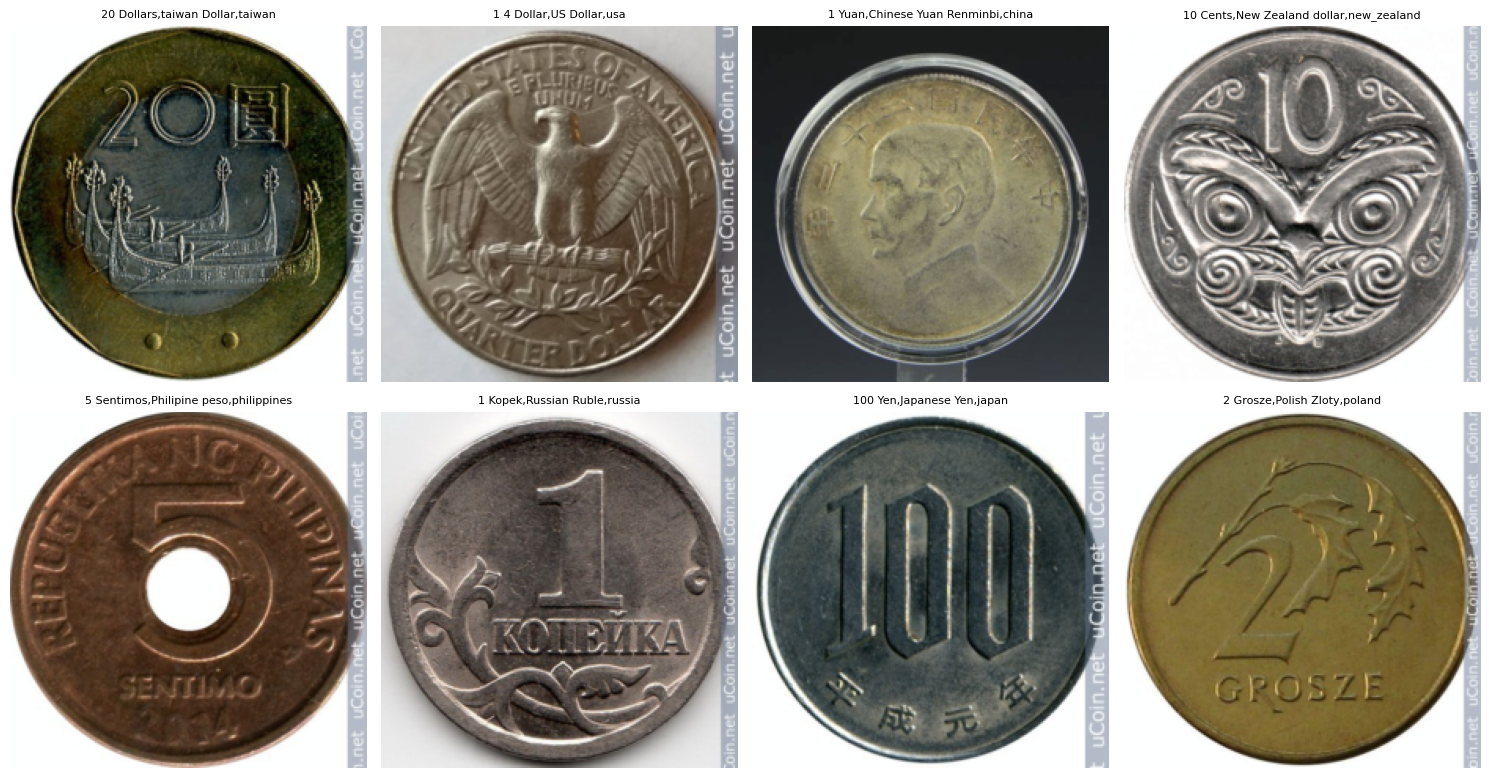

In [30]:
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title, fontsize=8)
    plt.axis('off')

images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    class_name = full_dataset.encoder.inverse_transform([labels[i]])[0]
    imshow(images[i], class_name)

plt.tight_layout()
plt.show()

##ARCHITECTURE ALEXNET

In [31]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            # Layer 1: Conv + ReLU + LRN + MaxPool
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Layer 2: Conv + ReLU + LRN + MaxPool
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Layer 3: Conv + ReLU
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Layer 4: Conv + ReLU
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Layer 5: Conv + ReLU + MaxPool
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.constant_(m.bias, 1)

        # Biais spécifiques : couches 2, 4, 5 en convolution ont un biais de 1
        nn.init.constant_(self.features[4].bias, 1)
        nn.init.constant_(self.features[10].bias, 1)
        nn.init.constant_(self.features[12].bias, 1)

##HYPER PARAMETRES

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du périphérique : {device}")

num_classes = len(full_dataset.encoder.classes_)
learning_rate = 0.001
num_epochs = 20

model = AlexNet(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"Modèle initialisé avec {num_classes} classes. Prêt pour l'entraînement.")

Utilisation du périphérique : cuda
Modèle initialisé avec 315 classes. Prêt pour l'entraînement.


##ENTRAINEMENT

In [42]:
for epoch in range(num_epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train

    model.eval()
    val_running_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}%")

print("Entraînement terminé !")

Epoch [1/20] | Train Loss: 6.6197, Acc: 1.03% | Val Loss: 5.5787, Acc: 1.40%
Epoch [2/20] | Train Loss: 5.5548, Acc: 1.54% | Val Loss: 5.5010, Acc: 1.83%
Epoch [3/20] | Train Loss: 5.4571, Acc: 2.21% | Val Loss: 5.3832, Acc: 3.42%
Epoch [4/20] | Train Loss: 5.3996, Acc: 2.59% | Val Loss: 5.2641, Acc: 4.87%
Epoch [5/20] | Train Loss: 5.1410, Acc: 4.62% | Val Loss: 5.0049, Acc: 5.50%
Epoch [6/20] | Train Loss: 4.8775, Acc: 6.69% | Val Loss: 4.7994, Acc: 7.77%
Epoch [7/20] | Train Loss: 4.6947, Acc: 8.26% | Val Loss: 4.6674, Acc: 10.08%
Epoch [8/20] | Train Loss: 4.5191, Acc: 10.38% | Val Loss: 4.5213, Acc: 11.67%
Epoch [9/20] | Train Loss: 4.3957, Acc: 11.49% | Val Loss: 4.4327, Acc: 12.25%
Epoch [10/20] | Train Loss: 4.2849, Acc: 12.75% | Val Loss: 4.2682, Acc: 14.38%
Epoch [11/20] | Train Loss: 4.1041, Acc: 14.85% | Val Loss: 4.2233, Acc: 15.82%
Epoch [12/20] | Train Loss: 3.9626, Acc: 16.94% | Val Loss: 4.0597, Acc: 19.10%
Epoch [13/20] | Train Loss: 3.8382, Acc: 18.26% | Val Loss: 4.

##GRAPHS


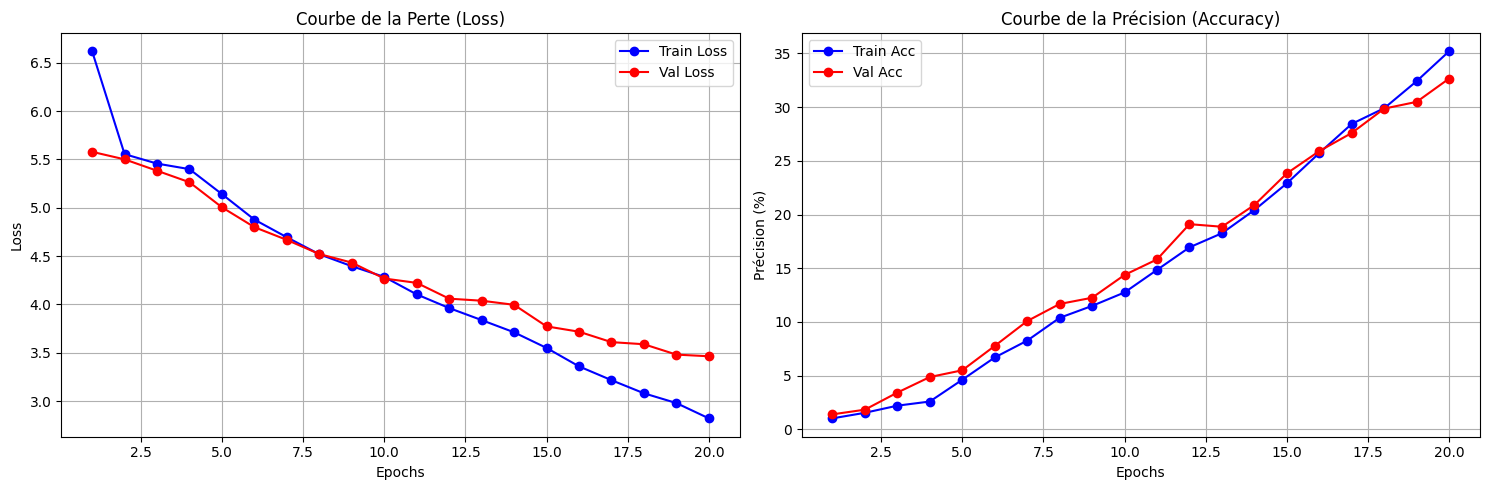

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# LOSS / EPOCH
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(range(1, num_epochs + 1), history['val_loss'], label='Val Loss', color='red', marker='o')
plt.title('Courbe de la Perte (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ACCURACY / EPOCH
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['train_acc'], label='Train Acc', color='blue', marker='o')
plt.plot(range(1, num_epochs + 1), history['val_acc'], label='Val Acc', color='red', marker='o')
plt.title('Courbe de la Précision (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Précision (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##PREDICTIONS SUR LE TEST.CSV POUR KAGGLE